In [1]:
import json

kaggle_config = {
    "username": "varadhadevanandan",
    "key": "YOUR_API_KEY"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_config, f)

print("kaggle.json file created")

kaggle.json file created


In [2]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets list

ref                                                          title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                             55017  2026-02-22 18:18:38.170000           3123         57  1.0              
likithagedipudi/starbucks-customer-ordering-patterns         Starbucks Customer Ordering Patterns                  2789356  2026-02-28 04:03:20.867000           1406         34  1.0              
suhanigupta04/student-placement-prediction-dataset           Student Placement Prediction Dataset                  1873115  2026-03-02 07:41:44.213000            826         27  1.0              
aliiihussain/amazon-

In [5]:
!kaggle datasets download -d sarangdilipjodh/indian-traffic-signs-prediction85-classes

Dataset URL: https://www.kaggle.com/datasets/sarangdilipjodh/indian-traffic-signs-prediction85-classes
License(s): CC0-1.0
100% 1.13G/1.13G [00:11<00:00, 200MB/s]
100% 1.13G/1.13G [00:11<00:00, 103MB/s]


In [6]:
!unzip indian-traffic-signs-prediction85-classes.zip

Streaming output truncated to the last 5000 lines.
  inflating: traffic_sign_classification_dataset/test/SLIPPERY_ROAD/61048.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63000.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63004.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63008.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63012.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63016.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63020.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63024.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63028.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63032.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63036.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED

In [9]:
import os
print(os.listdir())

['.config', 'traffic_sign_classification_dataset', 'indian-traffic-signs-prediction85-classes.zip', 'sample_data']


1️⃣ Import Required Libraries

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

2️⃣ Data Generators (Training + Validation)

In [10]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    '/content/traffic_sign_classification_dataset/train',
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    '/content/traffic_sign_classification_dataset/test',
    target_size=(64,64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4438 images belonging to 85 classes.
Found 1288 images belonging to 85 classes.


3️⃣ Build CNN Model

In [11]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 3
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_generator.num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4️⃣ Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

5️⃣ Train the Model

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 49s 339ms/step - accuracy: 0.0956 - loss: 4.0312 - val_accuracy: 0.3005 - val_loss: 2.7004
Epoch 2/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 46s 332ms/step - accuracy: 0.3106 - loss: 2.6378 - val_accuracy: 0.4472 - val_loss: 2.0531
Epoch 3/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 48s 341ms/step - accuracy: 0.4241 - loss: 2.0718 - val_accuracy: 0.5303 - val_loss: 1.6555
Epoch 4/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 48s 343ms/step - accuracy: 0.4974 - loss: 1.7472 - val_accuracy: 0.6149 - val_loss: 1.3853
Epoch 5/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 333ms/step - accuracy: 0.5889 - loss: 1.4252 - val_accuracy: 0.6871 - val_loss: 1.2063
Epoch 6/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 48s 347ms/step - accuracy: 0.6361 - loss: 1.2148 - val_accuracy: 0.7415 - val_loss: 1.0591
Epoch 7/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 337ms/step - accuracy: 0.6952 - loss: 1.0673 - val_accuracy: 0.7609 - val_loss: 0.9362
Epoch 8/10
139/139 ━━━━━━━━━━━━━━━━━━━━ 47s 339ms/step - accuracy: 0.6988 - loss: 0

6️⃣ Plot Training Results

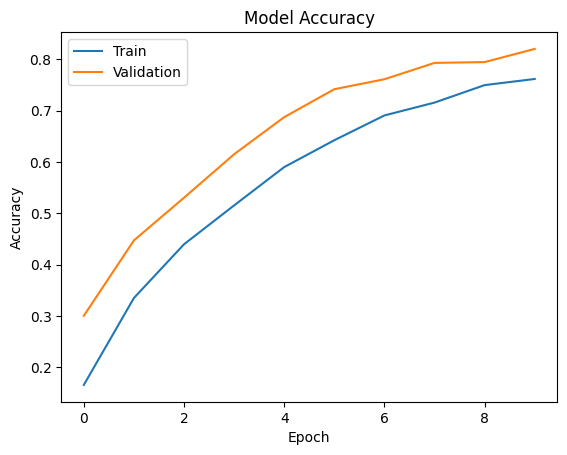

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(['Train','Validation'])
plt.show()

7️⃣ Test the Model on Test Dataset

In [15]:
test_loss, test_acc = model.evaluate(val_generator)

print("Test Accuracy:", test_acc)

41/41 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.7590 - loss: 1.1082
Test Accuracy: 0.8198757767677307


8️⃣ Visual Test on a Single Image

Choose an image from the test folder.

In [18]:
img_path = "/content/traffic_sign_classification_dataset/test/CATTLE/05036.jpg"

img = image.load_img(img_path,target_size=(64,64))
img_array = image.img_to_array(img)

img_array = img_array/255.0
img_array = np.expand_dims(img_array,axis=0)

prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


9️⃣ Convert Prediction to Class Name

In [19]:
class_indices = train_generator.class_indices
classes = list(class_indices.keys())

predicted_class = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

Predicted Class: CATTLE


argmax() = find the class with the highest probability.

🔟 Display the Image Visually


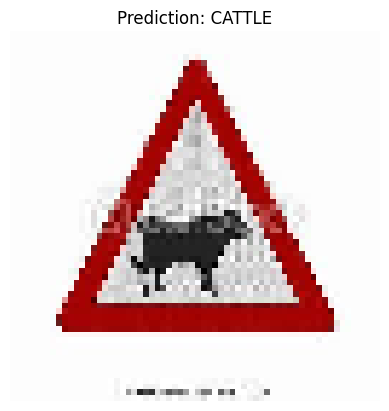

In [20]:
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


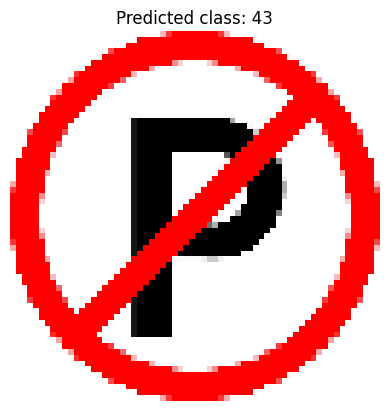

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = "/content/download.png"

# load image
img = image.load_img(img_path, target_size=(64,64))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = model.predict(img_array)

predicted_class_2 = np.argmax(prediction)

# show image
plt.imshow(img)
plt.title(f"Predicted class: {predicted_class_2}")
plt.axis("off")
plt.show()

In [30]:
class_indices = train_generator.class_indices
classes = list(class_indices.keys())

predicted_class_2 = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class_2)

Predicted Class: NO_PARKING
